In [1]:
#Baseline Model Rentals

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:


df = pd.read_csv("../raw_data/rentals.csv")

# Display the first rows
df.head()

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,...,transit_line,transit_distance_min,to_brandenburg_gate_km,kaltmiete_eur_monthly,nebenkosten_eur_monthly,warmmiete_eur_monthly,rent_per_m2_kalt_eur,rent_includes_warmmiete,kaution_months,warmmiete_eur_monthly_usd
0,R000001,2023-12-18,Adlershof,Treptow-Köpenick,medium,52.44391,13.53835,2_room,2,55.1,...,U7,203,13.53,517,281,798,9.37,False,3,861
1,R000002,2021-06-07,Lankwitz,Steglitz-Zehlendorf,medium,52.44035,13.33848,4_room,4,106.6,...,U8,111,8.85,1281,347,1628,12.03,True,3,1758
2,R000003,2022-08-19,Britz,Neukölln,low,52.44825,13.45215,3_room,3,102.5,...,U7,27,9.09,1366,524,1889,13.32,False,1,2041
3,R000004,2025-12-29,Hellersdorf,Marzahn-Hellersdorf,low,52.53063,13.62405,3_room,3,90.5,...,S Ringbahn,167,16.74,469,335,804,5.18,True,2,869
4,R000005,2022-07-18,Wartenberg,Lichtenberg,low,52.58212,13.50497,2_room,2,55.6,...,S Ringbahn,110,11.30,369,260,629,6.64,False,2,679


In [4]:
#Explore the data

In [5]:
df.shape

(30000, 30)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         30000 non-null  object 
 1   date_listed                30000 non-null  object 
 2   ortsteil                   30000 non-null  object 
 3   bezirk                     30000 non-null  object 
 4   kiez_premium               30000 non-null  object 
 5   lat                        30000 non-null  float64
 6   lon                        30000 non-null  float64
 7   property_type              30000 non-null  object 
 8   rooms                      30000 non-null  int64  
 9   area_m2                    30000 non-null  float64
 10  floor                      30000 non-null  int64  
 11  total_floors               30000 non-null  int64  
 12  building_era               30000 non-null  object 
 13  energy_class               30000 non-null  obj

In [7]:
df.describe()

,lat,lon,rooms,area_m2,floor,total_floors,transit_distance_min,to_brandenburg_gate_km,kaltmiete_eur_monthly,nebenkosten_eur_monthly,warmmiete_eur_monthly,rent_per_m2_kalt_eur,kaution_months,warmmiete_eur_monthly_usd
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,52.512407,13.390837,2.522667,75.587640,2.479367,4.951267,89.227100,10.106720,946.804133,265.886900,1212.689167,12.123417,2.500200,1309.704800
std,0.063742,0.125544,1.132488,37.465641,1.864499,1.384494,72.848119,4.612213,724.030300,142.681064,829.216366,5.483438,0.669588,895.554965
min,52.357930,13.113280,1.000000,20.000000,0.000000,3.000000,0.000000,0.230000,86.000000,50.000000,148.000000,2.550000,1.000000,160.000000
25%,52.461430,13.299788,2.000000,48.400000,1.000000,4.000000,27.000000,6.650000,458.000000,164.000000,643.000000,8.180000,2.000000,694.000000
50%,52.511570,13.386030,2.000000,68.700000,2.000000,5.000000,75.000000,9.690000,735.000000,237.000000,988.000000,10.780000,3.000000,1067.000000
75%,52.563122,13.480293,3.000000,94.100000,4.000000,6.000000,137.000000,13.210000,1203.000000,332.000000,1532.000000,14.800000,3.000000,1655.000000
max,52.658910,13.707070,5.000000,302.300000,8.000000,8.000000,424.000000,26.090000,7624.000000,1305.000000,8685.000000,46.400000,3.000000,9380.000000


In [8]:
df.isnull().sum().sort_values(ascending=False)

id                           0
date_listed                  0
kaution_months               0
rent_includes_warmmiete      0
rent_per_m2_kalt_eur         0
warmmiete_eur_monthly        0
nebenkosten_eur_monthly      0
kaltmiete_eur_monthly        0
to_brandenburg_gate_km       0
transit_distance_min         0
transit_line                 0
transit_station              0
furnished                    0
has_balcony                  0
has_lift                     0
condition                    0
position                     0
energy_class                 0
building_era                 0
total_floors                 0
floor                        0
area_m2                      0
rooms                        0
property_type                0
lon                          0
lat                          0
kiez_premium                 0
bezirk                       0
ortsteil                     0
warmmiete_eur_monthly_usd    0
dtype: int64

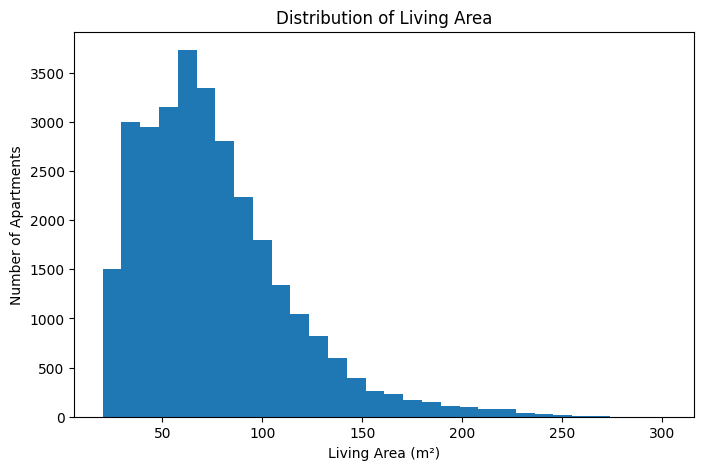

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["area_m2"], bins=30)

plt.title("Distribution of Living Area")
plt.xlabel("Living Area (m²)")
plt.ylabel("Number of Apartments")

plt.show()

In [10]:
df.columns

Index(['id', 'date_listed', 'ortsteil', 'bezirk', 'kiez_premium', 'lat', 'lon',
       'property_type', 'rooms', 'area_m2', 'floor', 'total_floors',
       'building_era', 'energy_class', 'position', 'condition', 'has_lift',
       'has_balcony', 'furnished', 'transit_station', 'transit_line',
       'transit_distance_min', 'to_brandenburg_gate_km',
       'kaltmiete_eur_monthly', 'nebenkosten_eur_monthly',
       'warmmiete_eur_monthly', 'rent_per_m2_kalt_eur',
       'rent_includes_warmmiete', 'kaution_months',
       'warmmiete_eur_monthly_usd'],
      dtype='object')

In [11]:
list(df.columns)

['id',
 'date_listed',
 'ortsteil',
 'bezirk',
 'kiez_premium',
 'lat',
 'lon',
 'property_type',
 'rooms',
 'area_m2',
 'floor',
 'total_floors',
 'building_era',
 'energy_class',
 'position',
 'condition',
 'has_lift',
 'has_balcony',
 'furnished',
 'transit_station',
 'transit_line',
 'transit_distance_min',
 'to_brandenburg_gate_km',
 'kaltmiete_eur_monthly',
 'nebenkosten_eur_monthly',
 'warmmiete_eur_monthly',
 'rent_per_m2_kalt_eur',
 'rent_includes_warmmiete',
 'kaution_months',
 'warmmiete_eur_monthly_usd']

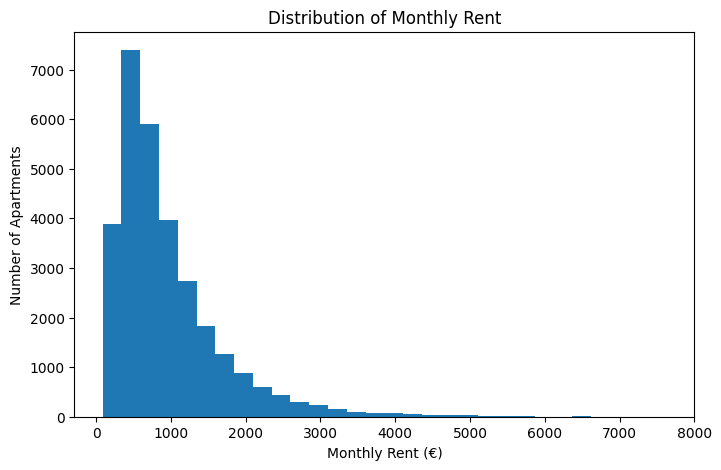

In [12]:
# Distribution of monthly rent

plt.figure(figsize=(8,5))

plt.hist(df["kaltmiete_eur_monthly"], bins=30)

plt.title("Distribution of Monthly Rent")
plt.xlabel("Monthly Rent (€)")
plt.ylabel("Number of Apartments")

plt.show()

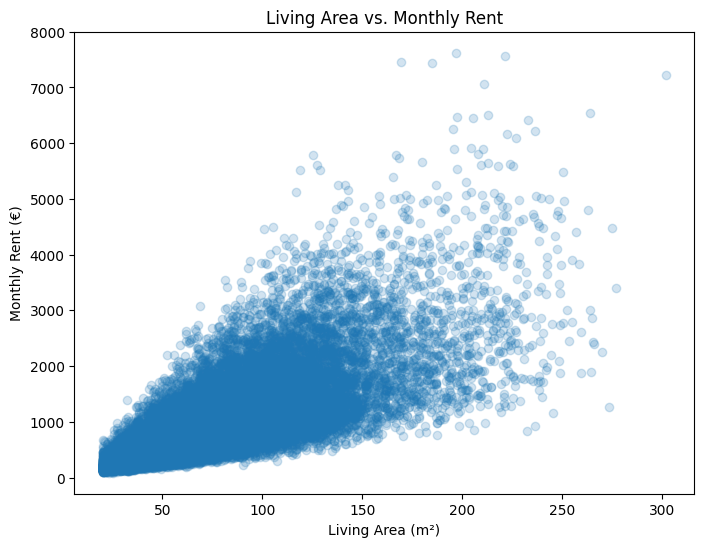

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["area_m2"],
    df["kaltmiete_eur_monthly"],
    alpha=0.2
)

plt.title("Living Area vs. Monthly Rent")
plt.xlabel("Living Area (m²)")
plt.ylabel("Monthly Rent (€)")

plt.show()

In [14]:
X = df[["area_m2"]]
y = df["kaltmiete_eur_monthly"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

LinearRegression()

In [18]:
# Predict rents

y_pred = model.predict(X_test)

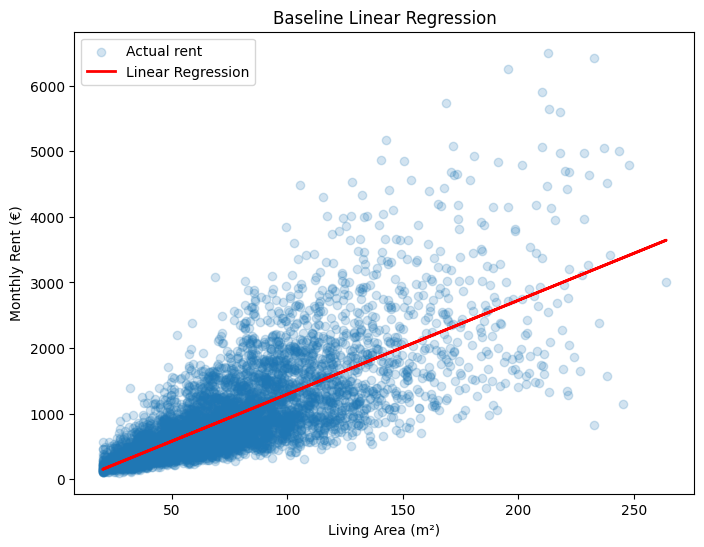

In [19]:
# Plot the regression line

plt.figure(figsize=(8,6))

# Scatter plot of the test data
plt.scatter(
    X_test,
    y_test,
    alpha=0.2,
    label="Actual rent"
)

# Regression line
plt.plot(
    X_test,
    y_pred,
    color="red",
    linewidth=2,
    label="Linear Regression"
)

plt.title("Baseline Linear Regression")
plt.xlabel("Living Area (m²)")
plt.ylabel("Monthly Rent (€)")
plt.legend()

plt.show()

In [20]:
# Evaluate the baseline model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} €")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} €")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error (MAE): 333.32 €
Root Mean Squared Error (RMSE): 495.53 €
R² Score: 0.549


In [21]:
####

In [22]:
#Multiple Linear Regression

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("../raw_data/df_sales_clean.csv")
df.head()

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,...,condition_renovierungsbedürftig,condition_saniert,building_era_modern_1990_2010.1,building_era_new_post_2010.1,building_era_post_war_1949_1990.1,position_hinterhaus.1,position_seitenflügel.1,position_vorderhaus.1,energy_class_ordinal,condition_ordinal
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,...,False,True,False,True,False,True,False,False,2.0,0.0
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,...,False,False,False,True,False,False,False,True,2.0,1.0
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,...,False,False,False,False,True,True,False,False,7.0,1.0
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,...,False,False,False,False,True,False,True,False,3.0,1.0
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,...,True,False,False,False,False,False,True,False,5.0,3.0


In [24]:
df.columns

Index(['id', 'date_listed', 'ortsteil', 'bezirk', 'kiez_premium', 'lat', 'lon',
       'property_type', 'rooms', 'area_m2', 'floor', 'total_floors',
       'year_built', 'has_lift', 'has_balcony', 'has_cellar', 'has_parking',
       'transit_station', 'transit_line', 'transit_distance_min',
       'transit_distance_type', 'to_brandenburg_gate_km', 'price_eur',
       'price_per_m2_eur', 'mortgage_rate_at_listing', 'price_eur_log',
       'price_per_m2_eur_log', 'area_m2_log', 'is_top_floor',
       'is_ground_floor', 'building_era_modern_1990_2010',
       'building_era_new_post_2010', 'building_era_post_war_1949_1990',
       'energy_class_A_plus', 'energy_class_B', 'energy_class_C',
       'energy_class_D', 'energy_class_E', 'energy_class_F', 'energy_class_G',
       'energy_class_H', 'position_hinterhaus', 'position_seitenflügel',
       'position_vorderhaus', 'condition_modernisiert', 'condition_renoviert',
       'condition_renovierungsbedürftig', 'condition_saniert',
       'buil

In [25]:
# Target
y = df["price_eur_log"]

# Features
X = df.drop(columns=[
    "price_eur",
    "price_per_m2_eur",
    "price_per_m2_eur_log",
    "price_eur_log",
    "id",
    "date_listed",
    "ortsteil",
    "bezirk",
    "kiez_premium",
    "property_type",
    "transit_station",
    "transit_line",
    "transit_distance_type"
])

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
X_train.select_dtypes(include="object").columns

Index([], dtype='object')

In [28]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [29]:
y_pred = lr.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

MAE:  0.210
RMSE: 0.257
R²:   0.872


In [31]:
y_test_eur = np.exp(y_test)
y_pred_eur = np.exp(y_pred)

mae_eur = mean_absolute_error(y_test_eur, y_pred_eur)
rmse_eur = mean_squared_error(y_test_eur, y_pred_eur) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE:  €{mae_eur:,.0f}")
print(f"RMSE: €{rmse_eur:,.0f}")
print(f"R²:   {r2:.3f}")

MAE:  €64,516
RMSE: €100,046
R²:   0.872


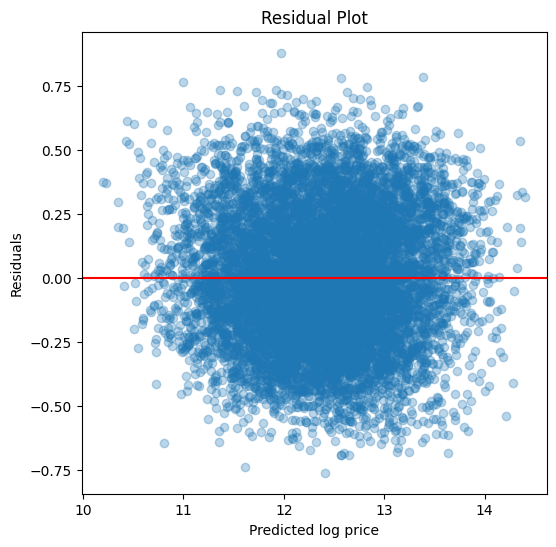

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_pred, y_test - y_pred, alpha=0.3)
plt.axhline(0, color="red")
plt.xlabel("Predicted log price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [33]:
pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}).head(10)

,Actual,Predicted
0,11.695255,11.858354
1,11.289794,11.289539
2,11.451061,11.264488
3,12.388398,12.900959
4,11.492733,11.185859
5,11.703554,12.084357
6,11.626263,11.960727
7,13.301348,12.974818
8,13.134294,13.287609
9,13.219492,12.925315


In [34]:
comparison = pd.DataFrame({
    "Actual (€)": np.exp(y_test),
    "Predicted (€)": np.exp(y_pred)
})

comparison.head(10)

,Actual (€),Predicted (€)
33553,120001.0,141259.525550
9427,80001.0,79980.584859
199,94001.0,78001.874414
12447,240001.0,400696.468696
39489,98001.0,72103.614886
42724,121001.0,177080.086256
10822,112001.0,156486.802007
49498,598001.0,431411.626106
4144,506001.0,589841.319865
36958,551001.0,410575.651640


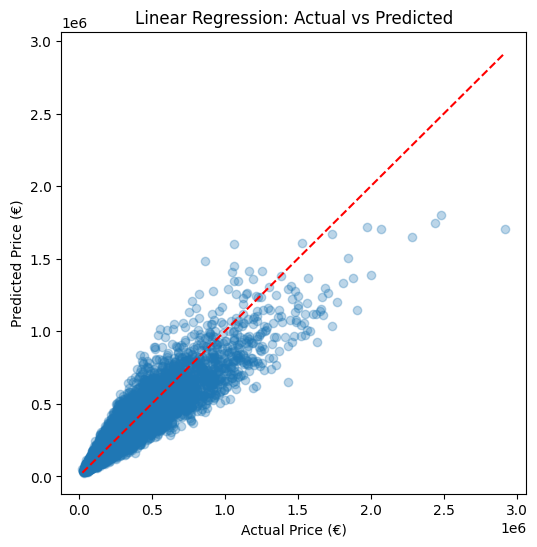

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(np.exp(y_test), np.exp(y_pred), alpha=0.3)
plt.plot(
    [np.exp(y_test).min(), np.exp(y_test).max()],
    [np.exp(y_test).min(), np.exp(y_test).max()],
    "r--"
)
plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [36]:
#Exploration K Means

In [37]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [38]:
features = df[[
    "area_m2",
    "rooms",
    "lat",
    "lon",
    "kiez_premium",
    "price_per_m2_eur"
]].copy()

In [39]:
features["kiez_premium"] = features["kiez_premium"].map({
    "low": 0,
    "medium": 1,
    "high": 2
})

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

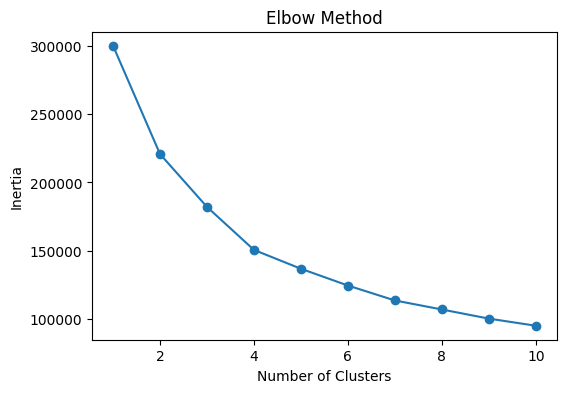

In [41]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [42]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

In [43]:
df.groupby("cluster")[[
    "price_per_m2_eur",
    "area_m2",
    "rooms"
]].mean().round(2)

,price_per_m2_eur,area_m2,rooms
cluster,,,
0,3023.82,59.53,2.02
1,6435.74,73.20,2.57
2,3995.27,133.90,4.21
3,2981.78,58.94,1.99


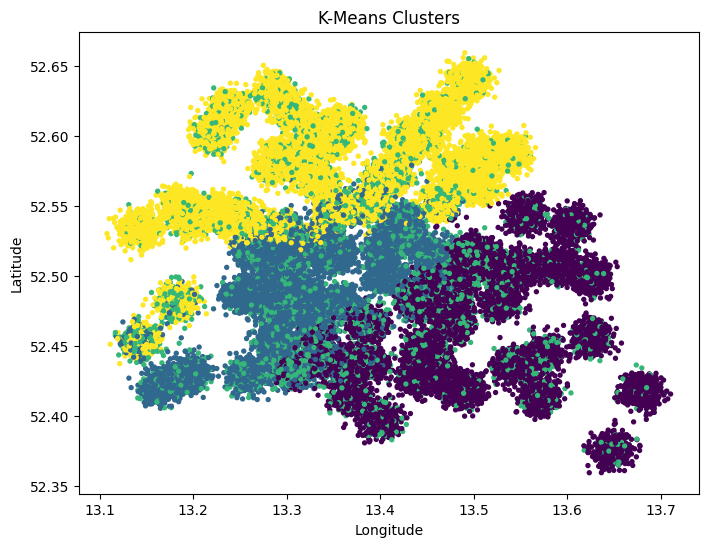

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["lon"],
    df["lat"],
    c=df["cluster"],
    cmap="viridis",
    s=8
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Clusters")
plt.show()

In [45]:
######

In [46]:
#New Construction - XGBoost

In [47]:
import pandas as pd

df = pd.read_csv("../raw_data/new_construction.csv")

df.head()

,id,date_listed,project_id,project_name,developer,ortsteil,bezirk,lat,lon,property_type,...,has_parking,transit_station,transit_line,transit_distance_min,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing
0,N000001,2024-05-20,NC0120,Kiez Moabit,STADT UND LAND,Moabit,Mitte,52.52846,13.34076,4_room,...,False,Kleistpark,U7,59,2.84,1335000,11646,1441922,12578,3.85
1,N000002,2024-02-06,NC0051,Platz Charlottenburg,GAGFAH,Charlottenburg,Charlottenburg-Wilmersdorf,52.51224,13.30218,3_room,...,True,Anhalter Bahnhof,S1,70,5.13,805000,11347,869116,12254,3.85
2,N000003,2022-11-10,NC0066,Höfe Lichterfelde,Adler Group,Lichterfelde,Steglitz-Zehlendorf,52.42957,13.30744,5_room_plus,...,True,Friedenau S,S1,65,10.75,1324000,10102,1430065,10910,3.40
3,N000004,2023-09-19,NC0067,Hofgarten Tiergarten,Berlinovo,Tiergarten,Mitte,52.51410,13.35763,5_room_plus,...,True,Theodor-Heuss-Platz,U2,72,1.38,3335000,13667,3601371,14761,4.10
4,N000005,2024-08-26,NC0115,Living Mariendorf,Berlinovo,Mariendorf,Tempelhof-Schöneberg,52.44131,13.39152,1_room,...,False,Bayerischer Platz,U7,79,8.39,263000,6129,283609,6619,3.50


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        10000 non-null  object 
 1   date_listed               10000 non-null  object 
 2   project_id                10000 non-null  object 
 3   project_name              10000 non-null  object 
 4   developer                 10000 non-null  object 
 5   ortsteil                  10000 non-null  object 
 6   bezirk                    10000 non-null  object 
 7   lat                       10000 non-null  float64
 8   lon                       10000 non-null  float64
 9   property_type             10000 non-null  object 
 10  rooms                     10000 non-null  int64  
 11  area_m2                   10000 non-null  float64
 12  floor                     10000 non-null  int64  
 13  total_floors              10000 non-null  int64  
 14  energy_

In [49]:
df.columns

Index(['id', 'date_listed', 'project_id', 'project_name', 'developer',
       'ortsteil', 'bezirk', 'lat', 'lon', 'property_type', 'rooms', 'area_m2',
       'floor', 'total_floors', 'energy_class', 'completion_year',
       'total_project_units', 'possession_status', 'payment_plan', 'has_lift',
       'has_balcony', 'has_parking', 'transit_station', 'transit_line',
       'transit_distance_min', 'to_brandenburg_gate_km', 'price_eur',
       'price_per_m2_eur', 'price_usd', 'price_per_m2_usd',
       'mortgage_rate_at_listing'],
      dtype='object')

In [50]:
df.describe()

,lat,lon,rooms,area_m2,floor,total_floors,completion_year,total_project_units,transit_distance_min,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,52.509339,13.396345,2.596100,77.684720,3.098000,6.183200,2026.321500,201.573000,90.116800,9.517486,6.340082e+05,7925.985700,6.847280e+05,8560.070000,2.928125
std,0.061348,0.118971,1.150781,38.431778,2.436389,2.290101,1.202116,177.611628,71.289114,4.794525,4.199080e+05,2503.402942,4.535016e+05,2703.674298,1.047260
min,52.372500,13.131290,1.000000,20.000000,0.000000,4.000000,2024.000000,20.000000,0.000000,1.300000,6.800000e+04,3116.000000,7.361600e+04,3366.000000,1.100000
25%,52.462400,13.305750,2.000000,49.900000,1.000000,5.000000,2025.000000,50.000000,30.000000,6.110000,3.390000e+05,6056.750000,3.656488e+05,6541.000000,1.800000
50%,52.505440,13.391520,2.000000,70.400000,3.000000,5.000000,2026.000000,120.000000,73.000000,8.750000,5.200000e+05,7288.000000,5.616970e+05,7871.000000,3.300000
75%,52.547990,13.479640,3.000000,97.700000,4.000000,6.000000,2027.000000,250.000000,136.000000,12.750000,8.090000e+05,9621.250000,8.739268e+05,10390.250000,3.850000
max,52.641470,13.687690,5.000000,300.300000,12.000000,12.000000,2028.000000,500.000000,405.000000,24.600000,3.470000e+06,18018.000000,3.747074e+06,19460.000000,4.100000


In [51]:
df.columns.tolist()

['id',
 'date_listed',
 'project_id',
 'project_name',
 'developer',
 'ortsteil',
 'bezirk',
 'lat',
 'lon',
 'property_type',
 'rooms',
 'area_m2',
 'floor',
 'total_floors',
 'energy_class',
 'completion_year',
 'total_project_units',
 'possession_status',
 'payment_plan',
 'has_lift',
 'has_balcony',
 'has_parking',
 'transit_station',
 'transit_line',
 'transit_distance_min',
 'to_brandenburg_gate_km',
 'price_eur',
 'price_per_m2_eur',
 'price_usd',
 'price_per_m2_usd',
 'mortgage_rate_at_listing']

In [52]:
df["floor"].value_counts().sort_index()

floor
0     1480
1     1542
2     1469
3     1483
4     1540
5     1097
6      608
7      231
8      254
9       76
10      73
11      69
12      78
Name: count, dtype: int64

In [53]:
# Future Engineering

In [54]:
# Ground floor / top floor features
df["is_ground_floor"] = (df["floor"] == 0).astype(int)

df["is_top_floor"] = (df["floor"] == df["total_floors"]).astype(int)

In [55]:
# Build modelling dataframe
df_model = df.copy()

In [56]:
energy_class_map = {
    "A_plus": 0,
    "A": 1,
    "B": 2,
    "C": 3,
    "D": 4,
    "E": 5,
    "F": 6,
    "G": 7,
    "H": 8
}

df_model["energy_class_ordinal"] = (
    df_model["energy_class"].map(energy_class_map)
)

assert df_model["energy_class_ordinal"].isna().sum() == 0, \
    "Unmapped energy class value"

In [57]:
df_model[["energy_class", "energy_class_ordinal"]].head(10)

,energy_class,energy_class_ordinal
0,A_plus,0
1,A,1
2,A_plus,0
3,A,1
4,B,2
5,A,1
6,A,1
7,A_plus,0
8,A_plus,0
9,A,1


In [58]:
# One-Hot Encoding for bezirk
bezirk_dummies = pd.get_dummies(
    df_model["bezirk"],
    prefix="bezirk",
    drop_first=True
)

# One-Hot Encoding for transit_line
transit_dummies = pd.get_dummies(
    df_model["transit_line"],
    prefix="transit",
    drop_first=True
)

# Add encoded columns
df_model = pd.concat(
    [df_model, bezirk_dummies, transit_dummies],
    axis=1
)

In [59]:
print(df_model.filter(like="bezirk").columns.tolist())

print(df_model.filter(like="transit").columns.tolist())

['bezirk', 'bezirk_Friedrichshain-Kreuzberg', 'bezirk_Lichtenberg', 'bezirk_Marzahn-Hellersdorf', 'bezirk_Mitte', 'bezirk_Neukölln', 'bezirk_Pankow', 'bezirk_Reinickendorf', 'bezirk_Spandau', 'bezirk_Steglitz-Zehlendorf', 'bezirk_Tempelhof-Schöneberg', 'bezirk_Treptow-Köpenick']
['transit_station', 'transit_line', 'transit_distance_min', 'transit_S1', 'transit_Stadtbahn', 'transit_U1', 'transit_U2', 'transit_U7', 'transit_U8']


In [60]:
[c for c in df_model.columns if c.startswith("transit_")]

['transit_station',
 'transit_line',
 'transit_distance_min',
 'transit_S1',
 'transit_Stadtbahn',
 'transit_U1',
 'transit_U2',
 'transit_U7',
 'transit_U8']

In [61]:
drop_cols = [
    "id",
    "date_listed",
    "project_id",
    "project_name",
    "developer",
    "property_type",
    "bezirk",
    "energy_class",
    "transit_line",
    "transit_station",
    "total_project_units",
    "possession_status",
    "payment_plan",
    "price_per_m2_eur",
    "price_usd",
    "price_per_m2_usd"
]

In [62]:
df_model = df_model.drop(columns=drop_cols)

In [63]:
TARGET = "price_eur"

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

In [64]:
from sklearn.model_selection import KFold


def target_encode_out_of_fold(
    train_series,
    train_target,
    test_series,
    n_splits=5,
    smoothing=10,
    random_state=42,
):
    """
    Leakage-safe target encoding for a single categorical column.
    """

    global_mean = train_target.mean()
    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    train_encoded = pd.Series(
        index=train_series.index,
        dtype=float
    )

    for fit_idx, holdout_idx in kf.split(train_series):

        fold_stats = (
            train_target.iloc[fit_idx]
            .groupby(train_series.iloc[fit_idx])
            .agg(["mean", "count"])
        )

        fold_smoothed = (
            fold_stats["mean"] * fold_stats["count"]
            + global_mean * smoothing
        ) / (fold_stats["count"] + smoothing)

        train_encoded.iloc[holdout_idx] = (
            train_series.iloc[holdout_idx]
            .map(fold_smoothed)
            .fillna(global_mean)
            .values
        )

    full_stats = (
        train_target
        .groupby(train_series)
        .agg(["mean", "count"])
    )

    full_smoothed = (
        full_stats["mean"] * full_stats["count"]
        + global_mean * smoothing
    ) / (full_stats["count"] + smoothing)

    test_encoded = (
        test_series
        .map(full_smoothed)
        .fillna(global_mean)
    )

    return train_encoded, test_encoded

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Train features: {X_train.shape}")
print(f"Test features: {X_test.shape}")

Train features: (8000, 34)
Test features: (2000, 34)


In [67]:
train_ortsteil_enc, test_ortsteil_enc = target_encode_out_of_fold(
    X_train["ortsteil"],
    y_train,
    X_test["ortsteil"]
)

X_train = X_train.drop(columns=["ortsteil"]).assign(
    ortsteil_target_enc=train_ortsteil_enc
)

X_test = X_test.drop(columns=["ortsteil"]).assign(
    ortsteil_target_enc=test_ortsteil_enc
)

print(f"Encoded {X['ortsteil'].nunique()} distinct ortsteil values")
print(f"Train features: {X_train.shape}")
print(f"Test features: {X_test.shape}")

Encoded 72 distinct ortsteil values
Train features: (8000, 34)
Test features: (2000, 34)


In [68]:
from sklearn.tree import DecisionTreeRegressor

In [69]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_regressor(model, model_name, X_train, X_test, y_train, y_test):
    """Fit `model` on the training set and report train/test performance.

    Returns a (results_dict, fitted_model) tuple so the caller can both build
    a comparison table and keep the fitted model around (e.g. for feature
    importances).
    """
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Target is already in EUR
    y_test_eur = y_test
    y_test_pred_eur = y_test_pred

    results = {
        "model": model_name,
        "train_r2": r2_score(y_train, y_train_pred),
        "test_r2": r2_score(y_test, y_test_pred),
        "test_mae_log": mean_absolute_error(y_test, y_test_pred),
        "test_rmse_log": mean_squared_error(y_test, y_test_pred) ** 0.5,
        "test_mae_eur": mean_absolute_error(y_test_eur, y_test_pred_eur),
        "test_rmse_eur": mean_squared_error(y_test_eur, y_test_pred_eur) ** 0.5,
    }

    print(f"--- {model_name} ---")
    print(f"Train R2: {results['train_r2']:.4f}")
    print(f"Test  R2: {results['test_r2']:.4f}")
    print(f"Test  MAE (EUR): €{results['test_mae_eur']:,.0f}")
    print(f"Test RMSE (EUR): €{results['test_rmse_eur']:,.0f}")

    return results, model


all_results = []

In [76]:
dt_results, dt_model = evaluate_regressor(
    DecisionTreeRegressor(random_state=42),
    "Decision Tree",
    X_train,
    X_test,
    y_train,
    y_test,
)

all_results.append(dt_results)

--- Decision Tree ---
Train R2: 1.0000
Test  R2: 0.9303
Test  MAE (EUR): €70,918
Test RMSE (EUR): €109,732


In [79]:
from xgboost import XGBRegressor

xgb_results, xgb_model = evaluate_regressor(
    XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
    ),
    "XGBoost",
    X_train,
    X_test,
    y_train,
    y_test,
)

all_results.append(xgb_results)

--- XGBoost ---
Train R2: 0.9917
Test  R2: 0.9709
Test  MAE (EUR): €45,488
Test RMSE (EUR): €70,904


<Figure size 1000x800 with 0 Axes>

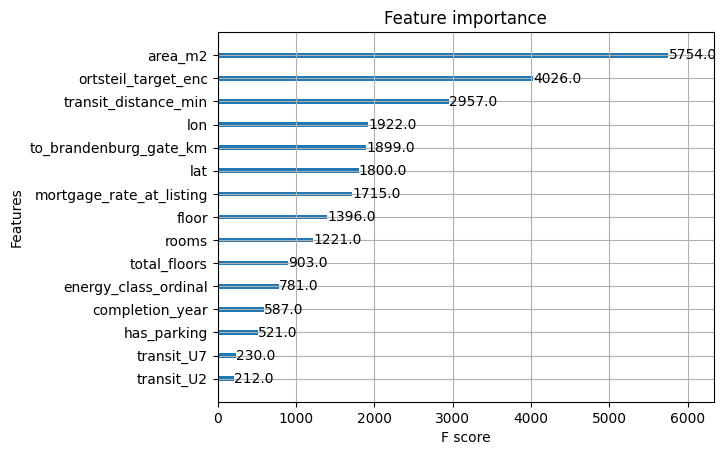

In [80]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=15)
plt.show()